#NOTE

In [1]:
#analisi fatta in ambiente google drive

In [2]:
# SI FA UNA ANALISI DI REGRESSIONE LINEARE MULTIPLA

# LIBRERIE

In [3]:
#librerie di base
import pandas as pd
import numpy as np

In [4]:
#libreria per l'analisi dei dati
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression as lr

In [5]:
#libreria di supporto per l'analisi

# per lo scaling delle variabili numeriche
from sklearn.preprocessing import StandardScaler
# per eseguire il trainin e il test e la valutazione del modello
from sklearn.model_selection import train_test_split as envtest

In [6]:
#librerie di valutazione e misurazione del modello
from sklearn import metrics

In [7]:
#librerie grafiche
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

#RECUPERO DATI

In [172]:
df_incidenti = pd.read_csv( ".//Analisi//Incidenti_flat.csv")

In [173]:
df_incidenti.head(4)

,Unnamed: 0,index,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,COMUNE,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE
0,0,0,2015,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2701,205.46,F,Feriti,9
1,1,1,2016,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2644,201.12,F,Feriti,8
2,2,2,2018,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2658,202.19,F,Feriti,1
3,3,3,2019,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2634,200.36,F,Feriti,5


In [174]:
df_incidenti.columns

Index(['Unnamed: 0', 'index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE'],
      dtype='object')

In [175]:
df_incidenti.TIME_PERIOD.unique()

array([2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2017])

In [11]:
df_incidenti = df_incidenti.drop('Unnamed: 0', axis=1)

In [12]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE'],
      dtype='object')

#PREPARAZIONE DATAFRAME DI ANALISI

##AMBITO DATI (CONTENUTO E TRASFORMAZIONI)

In [13]:
#feature : variabili indipendenti:  'TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'RESULT'
#   NB le altre sono relazionate tra loro per cui le derivo semplicemente sapendo una di quelle considerate come feature
#   NB COME FATTO IN SCRIPT PRECEDENTE LE VARIABILI IND. POP_RES E AREA_KMQ SONO STATE RIDOTTE A UNA SOLA POP_AL_KMQ CHE RACCOGLIE AMBEDUE LE INFORMAZIONI
#     RIDUCENDO GLI EFFETTI NEGATIVI DI INSERIRE PIù FEATURE E DOVE CORREGGERE IL RELATIVO EFFETTO - ES R QUADRO ADJUSTMENT
# variabile target: variabile dipendente: 'OBS_VALUE'
df_analisi = df_incidenti[['index','TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'RESULT','OBS_VALUE']]

In [14]:
df_analisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77736 entries, 0 to 77735
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        77736 non-null  int64  
 1   TIME_PERIOD  77736 non-null  int64  
 2   PRO_COM      77736 non-null  int64  
 3   POP_AL_KMQ   77736 non-null  float64
 4   RESULT       77736 non-null  object 
 5   OBS_VALUE    77736 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 3.6+ MB


In [15]:
df_analisi['RESULT'] = df_analisi['RESULT'].astype('string')

/tmp/ipykernel_51700/2194147801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analisi['RESULT'] = df_analisi['RESULT'].astype('string')


In [16]:
df_analisi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77736 entries, 0 to 77735
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        77736 non-null  int64  
 1   TIME_PERIOD  77736 non-null  int64  
 2   PRO_COM      77736 non-null  int64  
 3   POP_AL_KMQ   77736 non-null  float64
 4   RESULT       77736 non-null  string 
 5   OBS_VALUE    77736 non-null  int64  
dtypes: float64(1), int64(4), string(1)
memory usage: 3.6 MB


In [17]:
# LA COLONNA TESTUALE LA CONVERTO IN UNA FEATURE BOOLEAN
# SICCOME IL DOMINIO VALORI AMMESSO E' DI SOLO 2 VALORI CREO UNA SOLA COLONNA 0-1
# IN CUI DERIVO L'ALTRA QUANDO QUESTA E' 0 --> RIMUOVO LA DIPENDENZA TRA 2 COLONNE DATO CHE RIESCO A RICAVARE L'ALTRA
df_analisi['MORTI']=0

/tmp/ipykernel_51700/4177000675.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analisi['MORTI']=0


In [18]:
df_analisi[df_analisi['RESULT']=='M'].head(3)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
9,9,2023,1001,195.34,M,1,0
20,20,2023,1002,233.11,M,1,0
35,35,2018,1004,143.29,M,1,0


In [19]:
maschera_filtro= df_analisi['RESULT']=='M'
nr_morti= df_analisi[maschera_filtro]['MORTI'].agg('size')
nr_morti

16183

In [20]:
nr_feriti= df_analisi[~maschera_filtro]['MORTI'].agg('size')
nr_feriti

61553

In [21]:
nr_tot= df_analisi['RESULT'].agg('size')
nr_tot

77736

In [22]:
nr_tot_ver = nr_feriti + nr_morti
print(nr_tot_ver)

77736


In [23]:
df_analisi.loc[maschera_filtro,'MORTI']=1

In [24]:
df_analisi.groupby('MORTI').agg('size')

,0
MORTI,
0,61553
1,16183


In [25]:
#verifico eventuale correlazione tra le feature scelte :
# MATRICE DI CORRELAZIONE
df_analisi[['TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'MORTI']].corr()

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,MORTI
TIME_PERIOD,1.000000,0.009938,-0.004448,-0.017618
PRO_COM,0.009938,1.000000,0.008188,0.032555
POP_AL_KMQ,-0.004448,0.008188,1.000000,0.078191
MORTI,-0.017618,0.032555,0.078191,1.000000


In [26]:
#non esiste una forte correlazione tra le feature, la più alta è quello dei morti con la popolazione al kmq come ci si aspetterebbe
#ma il valore è tanto inferiore a 0.6 quindi non la ritengo correlata
# QUINDI NON SI EVIDENZIA SITUAZIONE DI MULTICOLLINEARITA'
0.078191 * 100

7.8191

##AMBITO ESPLORAZIONE VISIVA

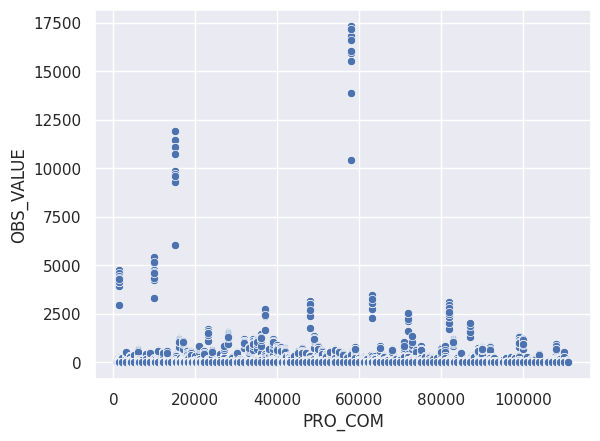

In [27]:
sns.scatterplot(x='PRO_COM', y='OBS_VALUE', data=df_analisi)
plt.show()

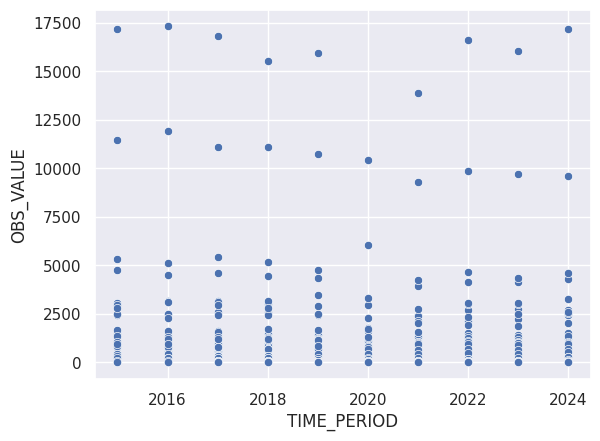

In [28]:
sns.scatterplot(x='TIME_PERIOD', y='OBS_VALUE', data=df_analisi)
plt.show()

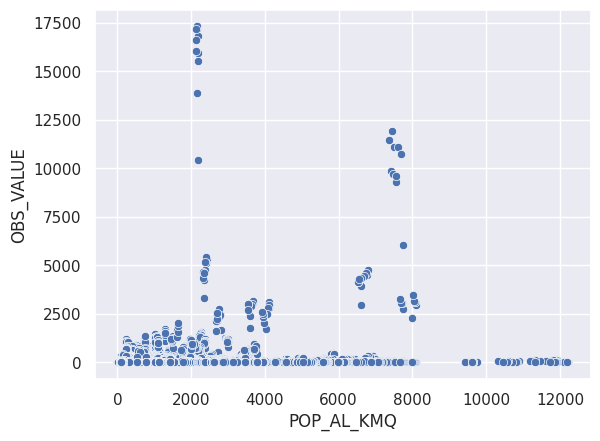

In [29]:
sns.scatterplot(x='POP_AL_KMQ', y='OBS_VALUE', data=df_analisi)
plt.show()

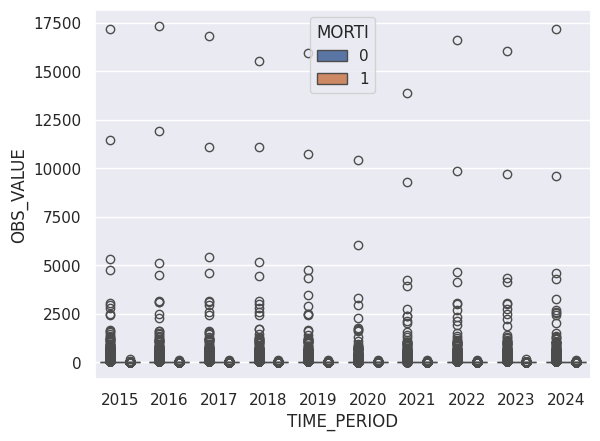

In [30]:
#sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE', hue='MORTI', data = df_analisi)
#sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE',  data = df_analisi)
sns.boxplot(x='TIME_PERIOD', y='OBS_VALUE', hue='MORTI', data = df_analisi)
plt.show()

In [31]:

#for feature in ['TIME_PERIOD','PRO_COM','POP_AL_KMQ']:
#    sns.boxplot(x=feature, y='MORTI', hue='OBS_VALUE', data = df_analisi)
#    plt.show()

#ANALISI CON MODELLO STATISTICO

##PREPARAZIONE DATASET DI ANALISI, TRAINING E TEST

In [32]:
# definizione delle variabile dipendente - target
Y_Target = df_analisi['OBS_VALUE']

In [33]:
# definizione delle feature - variabili indipendenti
X_Feature = df_analisi[['TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'MORTI']]

In [34]:
# aggiungo la costante
X_Feature = sm.add_constant(data=X_Feature)

In [35]:
# DEFINISCO GLI AMBIENTI DI TEST E TRAINING
X_train, X_test, Y_train, Y_test = envtest(X_Feature, Y_Target, test_size=0.3,random_state=2020)

In [36]:
#eseguo lo scaling ambiente Training
std_scaler = StandardScaler()
X_train_scaling = std_scaler.fit_transform(X_train)

In [37]:
#eseguo lo scaling ambiente test
std_scaler = StandardScaler()
X_test_scaling = std_scaler.fit_transform(X_test)

In [38]:
# definizione del modello statistico MULTI LINEAR REGRESSION
model_mlr= sm.OLS(Y_train ,X_train_scaling)

##ALLENAMENTO MODELLO

In [39]:
#allenamento del modello
MLR_Risultato=model_mlr.fit()

## VALUTAZIONE MODELLO

In [40]:
#lettura statistiche E LETTURA DEI PARAMETRI INTERNI
MLR_Risultato.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              OBS_VALUE   R-squared (uncentered):                   0.038
Model:                            OLS   Adj. R-squared (uncentered):              0.038
Method:                 Least Squares   F-statistic:                              532.4
Date:                Sun, 17 May 2026   Prob (F-statistic):                        0.00
Time:                        10:05:48   Log-Likelihood:                     -3.7641e+05
No. Observations:               54415   AIC:                                  7.528e+05
Df Residuals:                   54411   BIC:                                  7.529e+05
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const               0          0        nan        nan           0           0
x1            -1.8149      1.048     -1.732      0.083      -3.868       0.239
x2             1.5210      1.048      1.451      0.147      -0.533       3.575
x3            46.2413      1.050     44.034      0.000      44.183      48.300
x4           -17.5782      1.051    -16.728      0.000     -19.638     -15.519
==============================================================================
Omnibus:                   167984.140   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      18962017039.954
Skew:                          47.640   Prob(JB):                         0.00
Kurtosis:                    2893.365   Cond. No.                          inf
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The smallest eigenvalue is      0. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [41]:
# VALUTAZIONE DEL COEFFICIENTE DI DETERMINAZIONE
# mi serve a valutare il modello matematico scelto per eseguire la previsione statistica
# Valutazione R Quadro

# Valutazione R Quadro Adjustment

In [42]:
# Valutazione P_Value

##METRICHE DI PERFORMANCE DEL MODELLO MAE

In [43]:
# CALCOLO INDICE DI PERFORMANCE
# MAE - MEAN ABSOLUTE ERROR - ERRORE ASSOLUTO MEDIO
# MAE_TEST
def mae(y_reali, y_predetti):
    return round(np.mean(np.abs(y_reali - y_predetti)), 2)

###PREVISIONI SU DATASET DI VALUTAZIONE MODELLO

In [44]:
# eseguo le previsioni sui dati mai visti
Y_pred_test = MLR_Risultato.predict(X_test_scaling)

###RICAVO PERFORMANCE SU DATI DI TEST MAI VISTI DAL MODELLO

In [45]:
# MAE PREVISIONALE SU DATI DI TEST
MAE_TEST_SORG =  mae(Y_test , np.mean(Y_test))

In [46]:
# MAE PREVISIONALE SU DATI DI TRAINING
MAE_TEST_PREV =  mae(Y_test, np.mean(Y_pred_test))

In [47]:
print(f'MAE TEST SORGENTE       : {MAE_TEST_SORG}')
print(f'MAE TEST PREVISIONALE  : {MAE_TEST_PREV}')

MAE TEST SORGENTE       : 39.38
MAE TEST PREVISIONALE  : 29.98


###RICAVO PERFORMANCE SU DATI DI TRAININ VISTI DAL MODELLO

In [48]:
# leggo il valore di predizione sul dato di training
pred_train = MLR_Risultato.predict(X_train_scaling)

In [49]:
# MAE PREVISIONALE SU DATI DI TRAINING
MAE_TRAIN_SORG =  mae(Y_train, np.mean(Y_train))

In [50]:
# MAE PREVISIONALE SU DATI DI TRAINING
MAE_TRAIN_PREV =  mae(Y_train, np.mean(pred_train))

In [51]:
print(f'MAE TRAINING SORGENTE       : {MAE_TRAIN_SORG}')
print(f'MAE TRAINING PREVISIONALE  : {MAE_TRAIN_PREV}')

MAE TRAINING SORGENTE       : 38.6
MAE TRAINING PREVISIONALE  : 29.48


#METRICHE DI PERFORMANCE DEL MODELLO - CONFUSION MATRIX

In [52]:
# non applicabile perchè il target non assume valori booleani
#cm = metrics.confusion_matrix(Y_test, Y_pred_test)

#FORECAST 2027

##preparazione dei dati

In [53]:
df_analisi.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

In [54]:
df_comuni_2026 = pd.read_csv( ".//Analisi//ElencoComuni.csv")

In [55]:
# semplificazione che non considero + valida:
# se prendo solo l'ultimo anno degli indicenti, non significa che il comune non esiste
# ma solo che non ha avuto morti e feriti
# quindi l'elenco lo prendo dai comuni 2026

In [56]:
df_comuni_2026.columns

Index(['Unnamed: 0', 'anno_riferimento', 'COD_UTS', 'PRO_COM', 'COMUNE',
       'AREA_KMQ', 'POP_RES'],
      dtype='object')

In [57]:
df_comuni_2026 = df_comuni_2026.drop('COD_UTS',axis=1)

In [58]:
df_comuni_2026 = df_comuni_2026.drop('COMUNE',axis=1)

In [59]:
df_comuni_2026[df_comuni_2026.anno_riferimento==2026]['anno_riferimento'].unique()

array([2026])

In [60]:
df_comuni_2026 = df_comuni_2026[df_comuni_2026.anno_riferimento==2026]

In [61]:
df_comuni_2026['anno_riferimento'].unique()

array([2026])

In [62]:
df_comuni_2026['anno_riferimento'].size

7895

In [63]:
df_comuni_2026 = df_comuni_2026.drop('anno_riferimento',axis=1)

In [64]:
df_comuni_2026.columns

Index(['Unnamed: 0', 'PRO_COM', 'AREA_KMQ', 'POP_RES'], dtype='object')

In [65]:
df_comuni_2026.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7895 entries, 87316 to 95210
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7895 non-null   int64  
 1   PRO_COM     7895 non-null   int64  
 2   AREA_KMQ    7895 non-null   float64
 3   POP_RES     7895 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 308.4 KB


In [66]:
df_comuni_2026['POP_AL_KMQ']= round(df_comuni_2026['POP_RES'] / df_comuni_2026['AREA_KMQ'] ,2)

In [67]:
df_comuni_2026[['POP_RES','AREA_KMQ','POP_AL_KMQ']]

,POP_RES,AREA_KMQ,POP_AL_KMQ
87316,2585,13.1463,196.63
87317,3695,15.7393,234.76
87318,463,46.3316,9.99
87319,1624,11.7397,138.33
87320,6297,17.8741,352.30
...,...,...,...
95206,10490,88.0162,119.18
95207,982,31.0025,31.67
95208,3298,91.3873,36.09
95209,1015,36.4281,27.86


In [68]:
df_comuni_2026 = df_comuni_2026.drop('POP_RES',axis=1)

In [69]:
df_comuni_2026 = df_comuni_2026.drop('AREA_KMQ',axis=1)

In [70]:
df_comuni_2026.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7895 entries, 87316 to 95210
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7895 non-null   int64  
 1   PRO_COM     7895 non-null   int64  
 2   POP_AL_KMQ  7895 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 246.7 KB


In [71]:
# semplificazione che non considero + valida:
# se prendo solo l'ultimo anno degli indicenti, non significa che il comune non esiste
# ma solo che non ha avuto morti e feriti
# quindi l'elenco lo prendo dai comuni 2026
#
# basato su dati degli incidenti filtrati
#df_forecast_feriti = df_analisi.groupby(['PRO_COM', 'POP_AL_KMQ'], as_index=False).size()
#
# basato su tutti i comuni
df_forecast_feriti = df_comuni_2026.copy()


In [72]:
df_forecast_feriti.head()

,Unnamed: 0,PRO_COM,POP_AL_KMQ
87316,87327,1001,196.63
87317,87328,1002,234.76
87318,87329,1003,9.99
87319,87330,1004,138.33
87320,87331,1006,352.30


In [73]:
df_forecast_feriti.reset_index()

,index,Unnamed: 0,PRO_COM,POP_AL_KMQ
0,87316,87327,1001,196.63
1,87317,87328,1002,234.76
2,87318,87329,1003,9.99
3,87319,87330,1004,138.33
4,87320,87331,1006,352.30
...,...,...,...,...
7890,95206,95218,119020,119.18
7891,95207,95219,119021,31.67
7892,95208,95220,119022,36.09
7893,95209,95221,119023,27.86


In [74]:
df_forecast_feriti['TIME_PERIOD']= 2027

In [75]:
df_forecast_feriti['OBS_VALUE']= 0

In [76]:
df_forecast_feriti['MORTI']= 0

In [77]:
df_forecast_feriti['RESULT']= 'F'

In [78]:
#presente se si eseguiva il group by dagli incidenti
#df_forecast_feriti = df_forecast_feriti.drop('size',axis=1)

In [79]:
df_forecast_feriti.columns

Index(['Unnamed: 0', 'PRO_COM', 'POP_AL_KMQ', 'TIME_PERIOD', 'OBS_VALUE',
       'MORTI', 'RESULT'],
      dtype='object')

In [80]:
df_analisi.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

In [81]:
# voglio il medesimo ordine delle colonne
df_forecast_feriti= df_forecast_feriti[['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE', 'MORTI']]

In [82]:
df_forecast_feriti.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE', 'MORTI'], dtype='object')

In [83]:
df_forecast_morti = df_forecast_feriti.copy()

In [84]:
df_forecast_morti['RESULT']= 'M'

In [85]:
df_forecast_morti['MORTI']= 1

In [86]:
df_forecast_morti.head(5)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
87316,2027,1001,196.63,M,0,1
87317,2027,1002,234.76,M,0,1
87318,2027,1003,9.99,M,0,1
87319,2027,1004,138.33,M,0,1
87320,2027,1006,352.30,M,0,1


In [87]:
df_forecast = pd.concat([df_forecast_feriti, df_forecast_morti])

In [88]:
df_forecast.sample(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
88871,2027,13135,1302.86,F,0,0
87515,2027,1205,119.85,F,0,0
88132,2027,5093,74.42,M,0,1


In [89]:
df_forecast_feriti.head(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
87316,2027,1001,196.63,F,0,0
87317,2027,1002,234.76,F,0,0
87318,2027,1003,9.99,F,0,0


In [90]:
df_forecast_morti.head(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
87316,2027,1001,196.63,M,0,1
87317,2027,1002,234.76,M,0,1
87318,2027,1003,9.99,M,0,1


In [91]:
rows_feriti, columns = df_forecast_feriti.shape
print(rows_feriti)

7895


In [92]:
rows_morti, columns = df_forecast_morti.shape
print(rows_morti)

7895


In [93]:
rows_forecast, columns = df_forecast.shape
print(rows_forecast)

15790


In [94]:
print(f'{str(rows_feriti + rows_morti)}')

15790


In [95]:
df_forecast.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE', 'MORTI'], dtype='object')

In [96]:
df_forecast = df_forecast.reset_index()

In [97]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

In [98]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI
0,87316,2027,1001,196.63,F,0,0
1,87317,2027,1002,234.76,F,0,0
2,87318,2027,1003,9.99,F,0,0
3,87319,2027,1004,138.33,F,0,0
4,87320,2027,1006,352.30,F,0,0


In [99]:
df_forecast.head(5)['index']

,index
0,87316
1,87317
2,87318
3,87319
4,87320


## preparo la stima del forecast

In [100]:
# definizione della variabile dipendente - target
Y_Target_Forecast = df_forecast['OBS_VALUE']

In [101]:
# definizione delle feature - variabili indipendenti
X_Feature_Forecast = df_forecast[[ 'TIME_PERIOD','PRO_COM','POP_AL_KMQ', 'MORTI']]

In [102]:
X_Feature_Forecast.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [103]:
X_Feature_Forecast.head(3)

,TIME_PERIOD,PRO_COM,POP_AL_KMQ,MORTI
0,2027,1001,196.63,0
1,2027,1002,234.76,0
2,2027,1003,9.99,0


In [104]:
# aggiungo la costante
X_Feature_Forecast = sm.add_constant(data=X_Feature_Forecast)

In [105]:
X_train.columns

Index(['const', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI'], dtype='object')

In [106]:
X_train.const.unique()

array([1.])

In [107]:
# non ha fatto l'aggiunta della costante, quindi la inserisco io
X_Feature_Forecast['const'] = 1.

In [108]:
X_Feature_Forecast.columns

Index(['TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI', 'const'], dtype='object')

In [109]:
X_Feature_Forecast.const.unique()

array([1.])

In [110]:
#riordino i dati
X_Feature_Forecast = X_Feature_Forecast[['const', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'MORTI']]

In [111]:
#eseguo lo scaling ambiente Training
std_scaler_forecast = StandardScaler()
X_Feature_Forecast_Scaling = std_scaler_forecast.fit_transform(X_Feature_Forecast)

In [112]:
X_train_scaling

array([[ 0.        , -0.86084599,  0.63661564, -0.41009275, -0.51540442],
       [ 0.        ,  1.21769037,  0.7296955 , -0.28518585, -0.51540442],
       [ 0.        , -0.51442327, -1.39521381,  0.10491026,  1.94022395],
       ...,
       [ 0.        , -0.86084599, -0.09878532, -0.20935329, -0.51540442],
       [ 0.        ,  1.21769037,  0.98615886, -0.44441307, -0.51540442],
       [ 0.        ,  1.5641131 , -0.00315707, -0.47233468,  1.94022395]])

In [113]:
X_Feature_Forecast_Scaling

array([[ 0.        ,  0.        , -1.32126053, -0.16089699, -1.        ],
       [ 0.        ,  0.        , -1.32123123, -0.10080998, -1.        ],
       [ 0.        ,  0.        , -1.32120193, -0.45501287, -1.        ],
       ...,
       [ 0.        ,  0.        ,  2.13658662, -0.41388329,  1.        ],
       [ 0.        ,  0.        ,  2.13661592, -0.4268525 ,  1.        ],
       [ 0.        ,  0.        ,  2.13664522, -0.45034837,  1.        ]])

## eseguo la stima del forecast

In [114]:
# eseguo la previsione sul forecast
#utilizzo il modello allenato con il 70% dei dati storici
Y_pred_forecast = MLR_Risultato.predict(X_Feature_Forecast_Scaling)

##riporto la stima nei dati di forecast

In [115]:
#aggiungo la colonna row_num sul forecast per permettermi di asociare il target ai valori sorgenti
df_forecast["row_num"] = range(len(df_forecast))

In [116]:
type(Y_pred_forecast)

numpy.ndarray

In [117]:
dfforecast_target = df = pd.DataFrame({
    "row_num": range(len(Y_pred_forecast)),
    "target": Y_pred_forecast
})

In [118]:
dfforecast_target.columns

Index(['row_num', 'target'], dtype='object')

In [119]:
dfforecast_target.head(5)

,row_num,target
0,0,8.128484
1,1,10.907030
2,2,-5.471727
3,3,3.880346
4,4,19.472249


In [120]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'row_num'],
      dtype='object')

In [121]:
df_forecast.head(4)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num
0,87316,2027,1001,196.63,F,0,0,0
1,87317,2027,1002,234.76,F,0,0,1
2,87318,2027,1003,9.99,F,0,0,2
3,87319,2027,1004,138.33,F,0,0,3


In [122]:
dfforecast_target.head(4)

,row_num,target
0,0,8.128484
1,1,10.907030
2,2,-5.471727
3,3,3.880346


In [123]:
df_forecast = df_forecast.merge(dfforecast_target[['row_num','target']],
                                            how='inner',
                                            left_on='row_num',
                                            right_on='row_num')

In [124]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'row_num', 'target'],
      dtype='object')

In [125]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target
0,87316,2027,1001,196.63,F,0,0,0,8.128484
1,87317,2027,1002,234.76,F,0,0,1,10.907030
2,87318,2027,1003,9.99,F,0,0,2,-5.471727
3,87319,2027,1004,138.33,F,0,0,3,3.880346
4,87320,2027,1006,352.30,F,0,0,4,19.472249


In [126]:
df_forecast["target_int"] = np.floor(df["target"]).astype(int)

In [127]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,87316,2027,1001,196.63,F,0,0,0,8.128484,8
1,87317,2027,1002,234.76,F,0,0,1,10.907030,10
2,87318,2027,1003,9.99,F,0,0,2,-5.471727,-6
3,87319,2027,1004,138.33,F,0,0,3,3.880346,3
4,87320,2027,1006,352.30,F,0,0,4,19.472249,19


In [128]:
df_forecast.loc[df_forecast["target_int"] <0,'target_int']=0

In [129]:
df_forecast.head(5)

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,87316,2027,1001,196.63,F,0,0,0,8.128484,8
1,87317,2027,1002,234.76,F,0,0,1,10.907030,10
2,87318,2027,1003,9.99,F,0,0,2,-5.471727,0
3,87319,2027,1004,138.33,F,0,0,3,3.880346,3
4,87320,2027,1006,352.30,F,0,0,4,19.472249,19


In [130]:
df_forecast[df_forecast['target_int']>0]

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,87316,2027,1001,196.63,F,0,0,0,8.128484,8
1,87317,2027,1002,234.76,F,0,0,1,10.907030,10
3,87319,2027,1004,138.33,F,0,0,3,3.880346,3
4,87320,2027,1006,352.30,F,0,0,4,19.472249,19
6,87322,2027,1008,1383.81,F,0,0,6,94.637606,94
...,...,...,...,...,...,...,...,...,...,...
15701,95122,2027,118006,1729.38,M,0,1,15701,89.876363,89
15709,95130,2027,118014,675.31,M,0,1,15709,13.067524,13
15723,95144,2027,118028,2911.20,M,0,1,15723,175.995574,175
15733,95154,2027,118038,706.93,M,0,1,15733,15.372716,15


In [131]:
# prendo i soli dati significativi
df_forecast = df_forecast[df_forecast['target_int']>0]

In [132]:
df_forecast[df_forecast['target_int']<0]

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int


In [133]:
df_forecast['OBS_VALUE'] = df_forecast['target_int']

In [134]:
df_forecast[df_forecast['target_int']>0]

,index,TIME_PERIOD,PRO_COM,POP_AL_KMQ,RESULT,OBS_VALUE,MORTI,row_num,target,target_int
0,87316,2027,1001,196.63,F,8,0,0,8.128484,8
1,87317,2027,1002,234.76,F,10,0,1,10.907030,10
3,87319,2027,1004,138.33,F,3,0,3,3.880346,3
4,87320,2027,1006,352.30,F,19,0,4,19.472249,19
6,87322,2027,1008,1383.81,F,94,0,6,94.637606,94
...,...,...,...,...,...,...,...,...,...,...
15701,95122,2027,118006,1729.38,M,89,1,15701,89.876363,89
15709,95130,2027,118014,675.31,M,13,1,15709,13.067524,13
15723,95144,2027,118028,2911.20,M,175,1,15723,175.995574,175
15733,95154,2027,118038,706.93,M,15,1,15733,15.372716,15


In [135]:
df_forecast = df_forecast.drop(['row_num','target','target_int'],axis=1)

In [136]:
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5998 entries, 0 to 15743
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        5998 non-null   int64  
 1   TIME_PERIOD  5998 non-null   int64  
 2   PRO_COM      5998 non-null   int64  
 3   POP_AL_KMQ   5998 non-null   float64
 4   RESULT       5998 non-null   object 
 5   OBS_VALUE    5998 non-null   int64  
 6   MORTI        5998 non-null   int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 374.9+ KB


In [137]:
df_forecast['RESULT'] = df_forecast['RESULT'].astype('string')

In [138]:
df_forecast.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5998 entries, 0 to 15743
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        5998 non-null   int64  
 1   TIME_PERIOD  5998 non-null   int64  
 2   PRO_COM      5998 non-null   int64  
 3   POP_AL_KMQ   5998 non-null   float64
 4   RESULT       5998 non-null   string 
 5   OBS_VALUE    5998 non-null   int64  
 6   MORTI        5998 non-null   int64  
dtypes: float64(1), int64(5), string(1)
memory usage: 374.9 KB


##riporto la stima nei dati degli incidenti

In [139]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE'],
      dtype='object')

In [140]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI'],
      dtype='object')

In [141]:
df_comuni_flat = pd.read_csv( ".//Analisi//ElencoComuniProvinceRegioniRipGeografiche.csv")

In [142]:
df_comuni_flat.columns


Index(['Unnamed: 0', 'anno_riferimento', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ'],
      dtype='object')

In [143]:
df_comuni_flat = df_comuni_flat[df_comuni_flat['anno_riferimento']==2026]

In [144]:
df_comuni_flat.anno_riferimento.unique()

array([2026])

In [145]:
df_incidenti['TIPO_DATO'] ='S'
df_incidenti['TIPO_DATO_DSC'] ='Storico'

In [146]:
df_forecast['TIPO_DATO'] ='F'
df_forecast['TIPO_DATO_DSC'] ='Forecast'

In [147]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'TIPO_DATO', 'TIPO_DATO_DSC'],
      dtype='object')

In [148]:
df_forecast = df_forecast.merge(df_comuni_flat[['PRO_COM',
                                                'COD_RIP', 'DEN_RIP',
                                                'COD_REG', 'DEN_REG',
                                                'COD_UTS', 'DEN_UTS',
                                                'COMUNE',
                                                'AREA_KMQ','POP_RES']],
                                            how='inner',
                                            left_on='PRO_COM',
                                            right_on='PRO_COM')

In [149]:
df_forecast.columns

Index(['index', 'TIME_PERIOD', 'PRO_COM', 'POP_AL_KMQ', 'RESULT', 'OBS_VALUE',
       'MORTI', 'TIPO_DATO', 'TIPO_DATO_DSC', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'COMUNE', 'AREA_KMQ', 'POP_RES'],
      dtype='object')

In [150]:
df_forecast.TIME_PERIOD.unique()

array([2027])

In [151]:
df_incidenti.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO',
       'TIPO_DATO_DSC'],
      dtype='object')

In [152]:
df_incidenti.drop('index', axis=1)

,TIME_PERIOD,COD_RIP,DEN_RIP,COD_REG,DEN_REG,COD_UTS,DEN_UTS,PRO_COM,COMUNE,AREA_KMQ,POP_RES,POP_AL_KMQ,RESULT,RESULT_DESC,OBS_VALUE,TIPO_DATO,TIPO_DATO_DSC
0,2015,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2701,205.46,F,Feriti,9,S,Storico
1,2016,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2644,201.12,F,Feriti,8,S,Storico
2,2018,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2658,202.19,F,Feriti,1,S,Storico
3,2019,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2634,200.36,F,Feriti,5,S,Storico
4,2020,1,Nord-ovest,1,Piemonte,201,Torino,1001,Agliè,13.1462,2621,199.37,F,Feriti,4,S,Storico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77731,2021,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1937,2549,93.73,F,Feriti,7,S,Storico
77732,2022,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1943,2536,93.25,F,Feriti,1,S,Storico
77733,2023,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1943,2575,94.69,F,Feriti,5,S,Storico
77734,2024,5,Isole,20,Sardegna,111,Sud Sardegna,111107,Villaspeciosa,27.1943,2616,96.20,F,Feriti,5,S,Storico


In [156]:
df_forecast['RESULT_DESC']='Feriti'

In [157]:
df_forecast.loc[df_forecast['RESULT']=='M','RESULT_DESC'] = 'Morti'

In [158]:
df_forecast.groupby(['RESULT','RESULT_DESC']).agg('size')

,,0
RESULT,RESULT_DESC,
F,Feriti,4938
M,Morti,1060


In [160]:
df_forecast = df_forecast[['TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG',
       'DEN_REG', 'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ',
       'POP_RES', 'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE',
       'TIPO_DATO', 'TIPO_DATO_DSC']]

In [176]:
incidenti_forecast = pd.concat([df_incidenti, df_forecast])

In [164]:
incidenti_forecast.columns

Index(['index', 'TIME_PERIOD', 'COD_RIP', 'DEN_RIP', 'COD_REG', 'DEN_REG',
       'COD_UTS', 'DEN_UTS', 'PRO_COM', 'COMUNE', 'AREA_KMQ', 'POP_RES',
       'POP_AL_KMQ', 'RESULT', 'RESULT_DESC', 'OBS_VALUE', 'TIPO_DATO',
       'TIPO_DATO_DSC'],
      dtype='object')

In [171]:
incidenti_forecast.TIME_PERIOD.unique()

array([2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2017, 2027])

In [178]:
#caso vs:
#   importare le librerie come negli altri file
#  pd_common.SalvaDataset(df_incidenti_flat_an, f"Incidenti_flat",False)
#
incidenti_forecast.to_csv('.//Analisi//Incidenti_Forecast_flat.csv')